# Бинарная классификация изображений с зданиями и лесом

## TensorFlow/Keras

In [ ]:
import os
import shutil
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator    # Генератор обучающих данных
from tensorflow.keras.models import Sequential      # Контейнер модели
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization  # Типы используемых слоев
from tensorflow.keras.optimizers import Adam    # Алгоритм оптимизации
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from zipfile import ZipFile

Подготовка датасета:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/Colab Notebooks/AIPIT/4. Scenes - buildings vs forest.zip'

In [ ]:
LOCAL_DIR = '/content'

In [ ]:
# Распаковка архива с датасетом в сессионное хранилище
with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
len(os.listdir(os.path.join(LOCAL_DIR, 'dataset', 'test', '1 - buildings')))

450

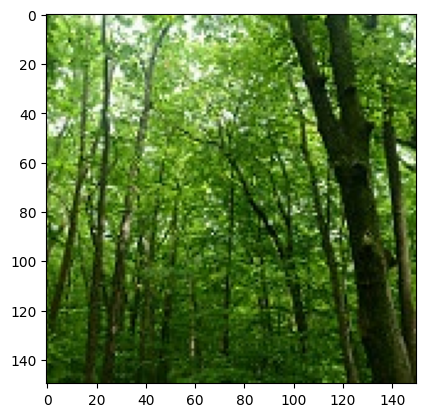

In [ ]:
plt.imshow(Image.open(os.path.join(LOCAL_DIR, 'dataset', 'train', '0 - forest', '8.jpg')));

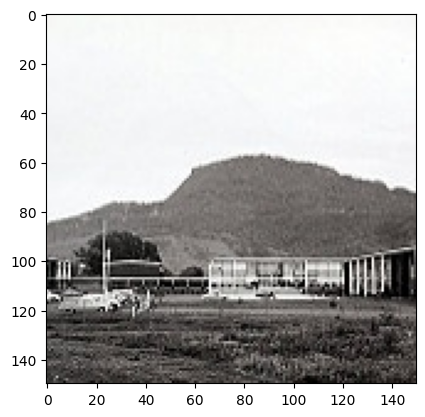

In [ ]:
plt.imshow(Image.open(os.path.join(LOCAL_DIR, 'dataset', 'train', '1 - buildings', '0.jpg')));

Построение модели:

In [ ]:
model = Sequential()
model.add(Input(shape=(150, 150, 3)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='SAME'))
model.add(MaxPooling2D())

model.add(Conv2D(64, (3, 3), activation='relu', padding='SAME'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Conv2D(128, (3, 3), activation='relu', padding='SAME'))
model.add(MaxPooling2D())
model.add(Conv2D(128, (3, 3), activation='relu', padding='SAME'))
model.add(MaxPooling2D())
model.add(Conv2D(128, (3, 3), activation='relu', padding='SAME'))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(rate=0.3))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 9, 9, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       663,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,052,353 (4.01 MB)

 Trainable params: 1,052,225 (4.01 MB)

 Non-trainable params: 128 (512.00 B)

Подготовка генераторов данных:

In [ ]:
# Сохраняем пути к папкам в переменные TRAIN_DIR, TEST_DIR
TRAIN_DIR = os.path.join(LOCAL_DIR, 'dataset/train')
TEST_DIR = os.path.join(LOCAL_DIR, 'dataset/test')

                                   rotation_range=10,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   zoom_range=0.1,
                                   shear_range=0.1,
                                   horizontal_flip=True,
                                   fill_mode='nearest'

In [ ]:
train_datagen = ImageDataGenerator(rescale=1/255,
                                   rotation_range=10,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   zoom_range=0.1,
                                   shear_range=0.5,
                                   horizontal_flip=True,
                                   fill_mode='nearest')
test_datagen = ImageDataGenerator(rescale=1/255)

In [ ]:
train_generator = train_datagen.flow_from_directory(TRAIN_DIR,
                                                    target_size=(150, 150),
                                                    batch_size=128,
                                                    shuffle=True,
                                                    class_mode='binary')

test_generator = test_datagen.flow_from_directory(TEST_DIR,
                                                    target_size=(150, 150),
                                                    batch_size=128,
                                                    shuffle=False,
                                                    class_mode='binary')

Found 3562 images belonging to 2 classes.
Found 900 images belonging to 2 classes.


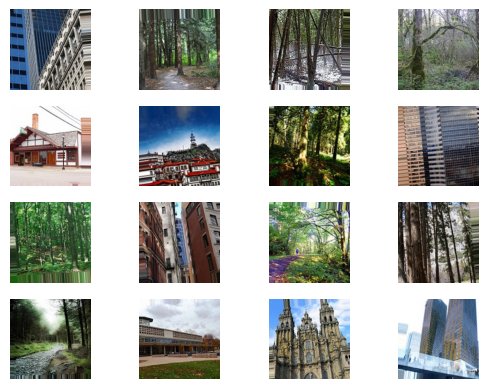

In [ ]:
x_batch, y_batch = next(train_generator)
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(x_batch[i])
    plt.axis('off')
plt.show()

Запуск обучения модели:

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.00005),
              metrics=['accuracy'])

In [ ]:
EPOCHS = 50

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
history = model.fit(
        train_generator,
        validation_data=test_generator,
        steps_per_epoch=30,
        epochs=EPOCHS,
        callbacks=[early_stopping]
      )

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
28/30 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.7198 - loss: 0.5452

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


30/30 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.7249 - loss: 0.5383 - val_accuracy: 0.5989 - val_loss: 0.6410
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 700ms/step - accuracy: 0.9038 - loss: 0.2532 - val_accuracy: 0.7111 - val_loss: 0.5952
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 22s 745ms/step - accuracy: 0.9234 - loss: 0.2027 - val_accuracy: 0.8111 - val_loss: 0.5501
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 753ms/step - accuracy: 0.9343 - loss: 0.1733 - val_accuracy: 0.8833 - val_loss: 0.5173
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 739ms/step - accuracy: 0.9362 - loss: 0.1638 - val_accuracy: 0.9033 - val_loss: 0.4987
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 707ms/step - accuracy: 0.9517 - loss: 0.1452 - val_accuracy: 0.8989 - val_loss: 0.4703
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 22s 745ms/step - accuracy: 0.9458 - loss: 0.1490 - val_accuracy: 0.9378 - val_loss: 0.4253
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 713ms/step - accuracy: 0.9530 - loss: 0.1363 - val_accuracy: 0.9078 -

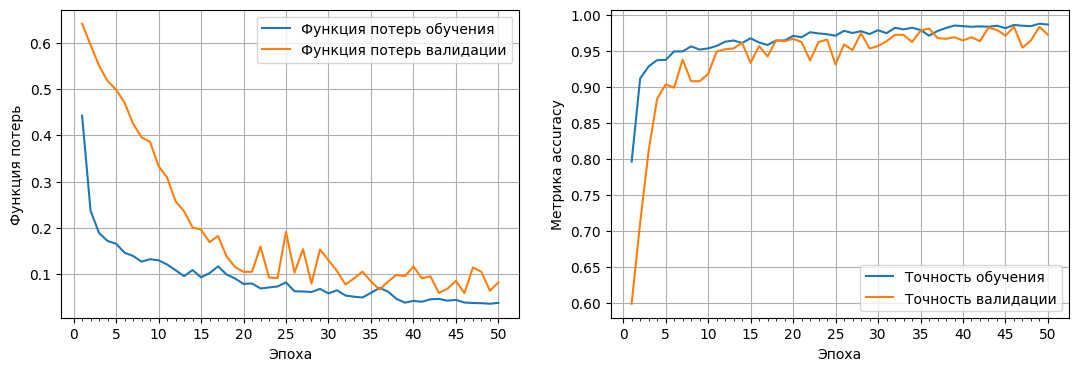

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].plot(np.arange(1, len(history.history['loss']) + 1), history.history['loss'][:], label='Функция потерь обучения')
axs[0].plot(np.arange(1, len(history.history['loss']) + 1), history.history['val_loss'][:], label='Функция потерь валидации')
axs[0].grid()
axs[0].set_xticks(np.arange(0, len(history.history['loss']) + 1, 5))
axs[0].set_xticks(np.arange(0, len(history.history['loss']) + 1, 1), minor=True)
axs[0].legend(prop={'size': 10})
axs[0].set_xlabel('Эпоха')
axs[0].set_ylabel('Функция потерь')

axs[1].plot(np.arange(1, len(history.history['accuracy']) + 1), history.history['accuracy'][:], label='Точность обучения')
axs[1].plot(np.arange(1, len(history.history['accuracy']) + 1), history.history['val_accuracy'][:], label='Точность валидации')
axs[1].grid()
axs[1].set_xticks(np.arange(0, len(history.history['accuracy']) + 1, 5))
axs[1].set_xticks(np.arange(0, len(history.history['accuracy']) + 1, 1), minor=True)
axs[1].legend(prop={'size': 10})
axs[1].set_xlabel('Эпоха')
axs[1].set_ylabel('Метрика accuracy')
plt.show()

Проверка модели на произвольных фотографиях:

In [ ]:
image = Image.open('/content/drive/MyDrive/Colab Notebooks/AIPIT/forest.jpg')

In [ ]:
image = image.resize((150, 150))

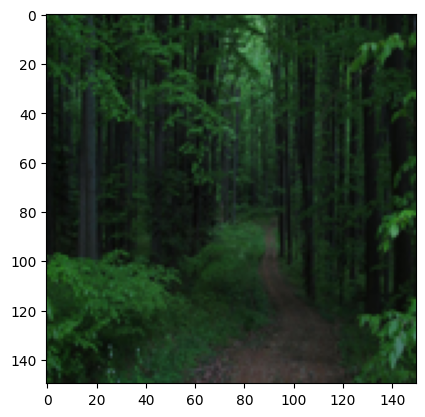

In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
image = np.array(image).reshape((1, 150, 150, 3))

In [ ]:
model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 807ms/step


array([[8.462153e-25]], dtype=float32)

In [ ]:
image = Image.open('/content/drive/MyDrive/Colab Notebooks/AIPIT/building.jpg')

In [ ]:
image = image.resize((150, 150))

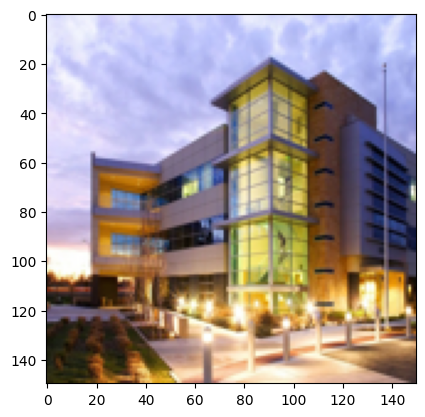

In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
image = np.array(image).reshape((1, 150, 150, 3))

In [ ]:
model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


array([[1.]], dtype=float32)

## PyTorch

In [ ]:
!pip install torchview

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
from torchview import draw_graph

Генераторы данных:

In [ ]:
transforms_train = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(
        degrees=10,                              # rotation_range
        translate=(0.1, 0.1),                    # width_shift_range, height_shift_range
        scale=(0.9, 1.1),                        # zoom_range (вокруг 1 ±0.1)
        shear=10,                                # shear_range
        fill=0                                    # fill_mode='nearest' — см. ниже
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transforms_test = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
# Сохраняем пути к папкам в переменные TRAIN_DIR, TEST_DIR
TRAIN_DIR = os.path.join(LOCAL_DIR, 'dataset/train')
TEST_DIR = os.path.join(LOCAL_DIR, 'dataset/test')

In [ ]:
# Создаем датасеты
dataset_train = datasets.ImageFolder(TRAIN_DIR, transforms_train)
dataset_test = datasets.ImageFolder(TEST_DIR, transforms_test)

In [ ]:
# Создаем data loaders
dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True, num_workers=2)
dataloader_test = DataLoader(dataset_test, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
# Get dataset sizes and class names
dataset_sizes_train = len(dataset_train)
dataset_sizes_test = len(dataset_test)
class_names = dataset_train.classes
print(f"Classes: {class_names}")
print(f"Dataset sizes: {dataset_sizes_train}, {dataset_sizes_test}")

Classes: ['0 - forest', '1 - buildings']
Dataset sizes: 3562, 900


Построение модели:

In [ ]:
+class ForestBuildingsCNN(nn.Module):
    def __init__(self):
        super(ForestBuildingsCNN, self).__init__()
        self.nn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(2048, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out = self.nn(x)
        return out

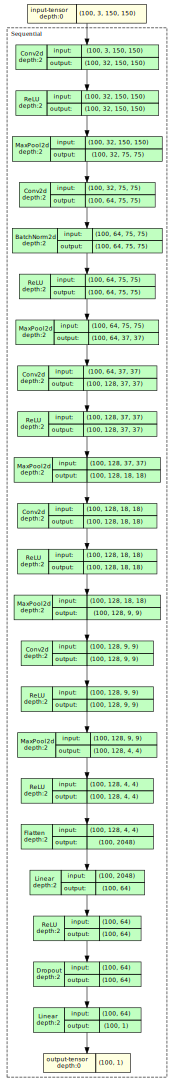

In [ ]:
model_pt = ForestBuildingsCNN()
model_graph = draw_graph(model_pt, input_size=(100, 3, 150, 150), expand_nested=True)
model_graph.visual_graph

In [ ]:
# Binary classification with a single output logit: criterion = nn.BCEWithLogitsLoss()
criterion = nn.BCEWithLogitsLoss()
# Multi-class classification with N output logits: criterion = nn.CrossEntropyLoss()

In [ ]:
LEARNING_RATE_PT = 0.00005
optimizer = optim.Adam(model_pt.parameters(), lr=LEARNING_RATE_PT)

In [ ]:
# Функция для проведения одной эпохи обучения
def train_one_epoch(model, epoch, train_data_loader, test_data_loader, optimizer, criterion, device):
    model.train()   # переводим модель в режим обучения, включая dropout и batchnorm слои
    total_loss, correct, test_total_loss, test_correct = 0, 0, 0, 0
    progress_bar = tqdm(train_data_loader, desc=f"Epoch {epoch}", leave=False)
    for images, labels in progress_bar:  # перебор обучающей выборки на одной эпохе
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()   # обнуление градиентов, которые остались с предыдущего шага
        outputs = model(images) # пропускаем данные батча через модель
        # Reshape labels for BCEWithLogitsLoss to match output shape [batch_size, 1]
        loss = criterion(outputs, labels.float().unsqueeze(1))   # вычисляем функцию потерь
        loss.backward() # обратное распространение ошибки
        optimizer.step()    # делаем шаг оптимизатора

        total_loss += loss.item()
        # For accuracy with BCEWithLogitsLoss, apply sigmoid and then threshold
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        correct += (predicted == labels.float().unsqueeze(1)).sum().item()

        progress_bar.set_postfix_str(f"Loss: {total_loss / len(train_data_loader):.4f}, Accuracy: {correct / len(train_data_loader.dataset):.4f}")

    # Подсчет метрик и функции потерь на тестовой выборке после окончания эпохи
    model.eval() # переводим модель в режим инференса
    with torch.no_grad():
        for images, labels in test_data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            # Reshape labels for BCEWithLogitsLoss to match output shape [batch_size, 1]
            loss = criterion(outputs, labels.float().unsqueeze(1))

            test_total_loss += loss.item()
            # For accuracy with BCEWithLogitsLoss, apply sigmoid and then threshold
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            test_correct += (predicted == labels.float().unsqueeze(1)).sum().item()

    train_loss = total_loss / len(train_data_loader)
    train_accuracy = correct / len(train_data_loader.dataset)
    test_loss = test_total_loss / len(test_data_loader)
    test_accuracy = test_correct / len(test_data_loader.dataset)
    return train_loss, train_accuracy, test_loss, test_accuracy

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model_pt.to(device)

Using device: cuda


ForestBuildingsCNN(
  (nn): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU()
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

In [ ]:
EPOCHS_PT = 50

In [ ]:

history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(EPOCHS_PT):
    train_loss, accuracy, val_loss, val_accuracy = train_one_epoch(model_pt, epoch, dataloader_train, dataloader_test, optimizer, criterion, device)
    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(accuracy)
    history["val_accuracy"].append(val_accuracy)
    print(f"\nEpoch {epoch+1}/{EPOCHS_PT}, Loss: {train_loss:.4f}, Accuracy: {accuracy:.4f}, Test Loss: {val_loss:.4f}, Test Accuracy: {val_accuracy:.4f}")

Epoch 0:   0%|          | 0/112 [00:00<?, ?it/s]


Epoch 1/50, Loss: 0.4688, Accuracy: 0.8077, Test Loss: 0.2408, Test Accuracy: 0.9178


Epoch 1:   0%|          | 0/112 [00:00<?, ?it/s]


Epoch 2/50, Loss: 0.2651, Accuracy: 0.8987, Test Loss: 0.2214, Test Accuracy: 0.9156


Epoch 2:   0%|          | 0/112 [00:00<?, ?it/s]

...


Epoch 48/50, Loss: 0.0553, Accuracy: 0.9812, Test Loss: 0.0591, Test Accuracy: 0.9822


Epoch 48:   0%|          | 0/112 [00:00<?, ?it/s]


Epoch 49/50, Loss: 0.0584, Accuracy: 0.9806, Test Loss: 0.0507, Test Accuracy: 0.9844


Epoch 49:   0%|          | 0/112 [00:00<?, ?it/s]


Epoch 50/50, Loss: 0.0565, Accuracy: 0.9789, Test Loss: 0.0582, Test Accuracy: 0.9811


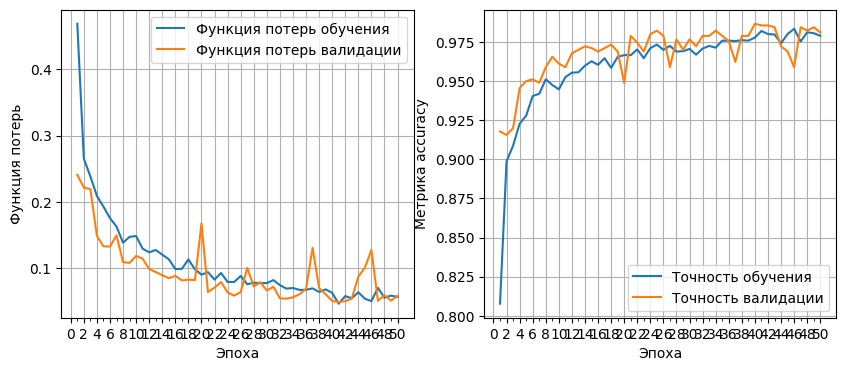

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(np.arange(1, EPOCHS_PT + 1), history['loss'], label='Функция потерь обучения')
axs[0].plot(np.arange(1, EPOCHS_PT + 1), history['val_loss'], label='Функция потерь валидации')
axs[0].grid()
axs[0].set_xticks(np.arange(0, EPOCHS_PT + 1, 2))
axs[0].set_xticks(np.arange(0, EPOCHS_PT + 1, 1), minor=True)
axs[0].legend(prop={'size': 10})
axs[0].set_xlabel('Эпоха')
axs[0].set_ylabel('Функция потерь')

axs[1].plot(np.arange(1, EPOCHS_PT + 1), history['accuracy'], label='Точность обучения')
axs[1].plot(np.arange(1, EPOCHS_PT + 1), history['val_accuracy'], label='Точность валидации')
axs[1].grid()
axs[1].set_xticks(np.arange(0, EPOCHS_PT + 1, 2))
axs[1].set_xticks(np.arange(0, EPOCHS_PT + 1, 1), minor=True)
axs[1].legend(prop={'size': 10})
axs[1].set_xlabel('Эпоха')
axs[1].set_ylabel('Метрика accuracy')
plt.show()

Работа модели:

In [ ]:
# Get one batch of test data
dataloader_test2 = DataLoader(dataset_test, batch_size=32, shuffle=True, num_workers=2)
dataiter = iter(dataloader_test2)
images, labels = next(dataiter)

# Move images to the same device
images = images.to(device)
model_pt.to(device)

# Make prediction
with torch.no_grad():
    outputs = model_pt(images)
    predicted = (torch.sigmoid(outputs) > 0.5).float()

# Print actual and predicted labels for the first few samples
print("Actual Labels:\t\t", labels[:20].cpu().numpy())
print("Predicted Labels:\t", predicted[:20].squeeze().cpu().numpy().astype(np.int64))

Actual Labels:		 [0 1 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 1 0 0]
Predicted Labels:	 [0 1 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 1 0 0]


## PyTorch (С предобученной моделью VGG19)

In [ ]:
!pip install torchview

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from torchvision import models
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
from torchview import draw_graph

Генераторы данных:

In [ ]:
transforms_train = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(
        degrees=10,                              # rotation_range
        translate=(0.1, 0.1),                    # width_shift_range, height_shift_range
        scale=(0.9, 1.1),                        # zoom_range (вокруг 1 ±0.1)
        shear=10,                                # shear_range
        fill=0                                    # fill_mode='nearest' — см. ниже
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transforms_test = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
# Сохраняем пути к папкам в переменные TRAIN_DIR, TEST_DIR
TRAIN_DIR = os.path.join(LOCAL_DIR, 'dataset/train')
TEST_DIR = os.path.join(LOCAL_DIR, 'dataset/test')

In [ ]:
# Создаем датасеты
dataset_train = datasets.ImageFolder(TRAIN_DIR, transforms_train)
dataset_test = datasets.ImageFolder(TEST_DIR, transforms_test)

In [ ]:
# Создаем data loaders
dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True, num_workers=2)
dataloader_test = DataLoader(dataset_test, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
# Get dataset sizes and class names
dataset_sizes_train = len(dataset_train)
dataset_sizes_test = len(dataset_test)
class_names = dataset_train.classes
print(f"Classes: {class_names}")
print(f"Dataset sizes: {dataset_sizes_train}, {dataset_sizes_test}")

Classes: ['0 - forest', '1 - buildings']
Dataset sizes: 3562, 900


Построение модели:

In [ ]:
class ForestBuildingsCNN(nn.Module):
    def __init__(self):
        super(ForestBuildingsCNN, self).__init__()

        #Добавляем VGG19 как параметр модели (слой)
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        self.conv_base = vgg.features

        self.nn = nn.Sequential(
            self.conv_base,
            nn.Flatten(),
            nn.Linear(8192, 256),
            nn.Dropout(0.3),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        out = self.nn(x)
        return out

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 107MB/s]


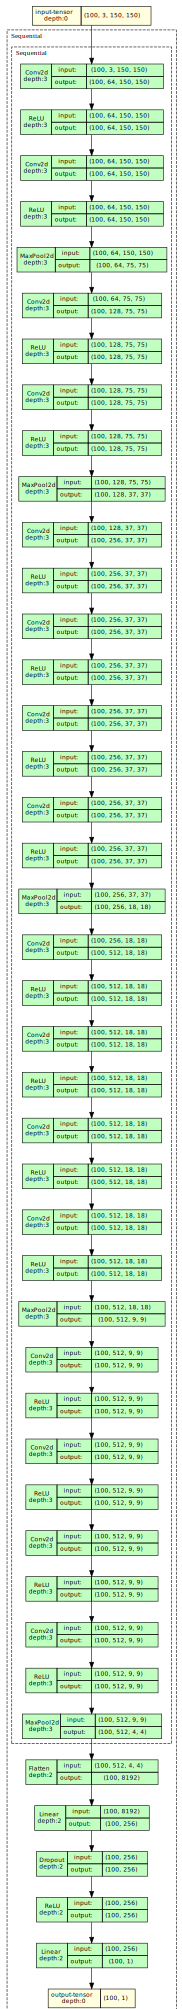

In [ ]:
model_pt = ForestBuildingsCNN()
model_graph = draw_graph(model_pt, input_size=(100, 3, 150, 150), expand_nested=True)
model_graph.visual_graph

In [ ]:
# Binary classification with a single output logit: criterion = nn.BCEWithLogitsLoss()
criterion = nn.BCEWithLogitsLoss()
# Multi-class classification with N output logits: criterion = nn.CrossEntropyLoss()

In [ ]:
LEARNING_RATE_PT = 0.0005

#Отключаем расчёт градиентов для VGG19 (замораживаем) - 1 этап
for p in model_pt.conv_base.parameters():
    p.requires_grad = False

optimizer = optim.Adam(model_pt.parameters(), lr=LEARNING_RATE_PT)

In [ ]:
# Функция для проведения одной эпохи обучения
def train_one_epoch(model, epoch, train_data_loader, test_data_loader, optimizer, criterion, device):
    model.train()   # переводим модель в режим обучения, включая dropout и batchnorm слои
    total_loss, correct, test_total_loss, test_correct = 0, 0, 0, 0
    progress_bar = tqdm(train_data_loader, desc=f"Epoch {epoch}", leave=False)
    for images, labels in progress_bar:  # перебор обучающей выборки на одной эпохе
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()   # обнуление градиентов, которые остались с предыдущего шага
        outputs = model(images) # пропускаем данные батча через модель
        # Reshape labels for BCEWithLogitsLoss to match output shape [batch_size, 1]
        loss = criterion(outputs, labels.float().unsqueeze(1))   # вычисляем функцию потерь
        loss.backward() # обратное распространение ошибки
        optimizer.step()    # делаем шаг оптимизатора

        total_loss += loss.item()
        # For accuracy with BCEWithLogitsLoss, apply sigmoid and then threshold
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        correct += (predicted == labels.float().unsqueeze(1)).sum().item()

        progress_bar.set_postfix_str(f"Loss: {total_loss / len(train_data_loader):.4f}, Accuracy: {correct / len(train_data_loader.dataset):.4f}")

    # Подсчет метрик и функции потерь на тестовой выборке после окончания эпохи
    model.eval() # переводим модель в режим инференса
    with torch.no_grad():
        for images, labels in test_data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            # Reshape labels for BCEWithLogitsLoss to match output shape [batch_size, 1]
            loss = criterion(outputs, labels.float().unsqueeze(1))

            test_total_loss += loss.item()
            # For accuracy with BCEWithLogitsLoss, apply sigmoid and then threshold
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            test_correct += (predicted == labels.float().unsqueeze(1)).sum().item()

    train_loss = total_loss / len(train_data_loader)
    train_accuracy = correct / len(train_data_loader.dataset)
    test_loss = test_total_loss / len(test_data_loader)
    test_accuracy = test_correct / len(test_data_loader.dataset)
    return train_loss, train_accuracy, test_loss, test_accuracy

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model_pt.to(device)

Using device: cuda


ForestBuildingsCNN(
  (conv_base): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), str

In [ ]:
EPOCHS_PT1 = 20
EPOCHS_PT2 = 10

In [ ]:

history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(EPOCHS_PT1):
    train_loss, accuracy, val_loss, val_accuracy = train_one_epoch(model_pt, epoch, dataloader_train, dataloader_test, optimizer, criterion, device)
    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(accuracy)
    history["val_accuracy"].append(val_accuracy)
    print(f"\nEpoch {epoch+1}/{EPOCHS_PT1}, Loss: {train_loss:.4f}, Accuracy: {accuracy:.4f}, Test Loss: {val_loss:.4f}, Test Accuracy: {val_accuracy:.4f}")

Epoch 0:   0%|          | 0/112 [00:00<?, ?it/s]


Epoch 1/20, Loss: 0.0287, Accuracy: 0.9891, Test Loss: 0.0222, Test Accuracy: 0.9900


Epoch 1:   0%|          | 0/112 [00:00<?, ?it/s]


Epoch 2/20, Loss: 0.0038, Accuracy: 0.9992, Test Loss: 0.0162, Test Accuracy: 0.9933


Epoch 2:   0%|          | 0/112 [00:00<?, ?it/s]

...


Epoch 18/20, Loss: 0.0066, Accuracy: 0.9983, Test Loss: 0.0184, Test Accuracy: 0.9956


Epoch 18:   0%|          | 0/112 [00:00<?, ?it/s]


Epoch 19/20, Loss: 0.0016, Accuracy: 0.9997, Test Loss: 0.0158, Test Accuracy: 0.9978


Epoch 19:   0%|          | 0/112 [00:00<?, ?it/s]


Epoch 20/20, Loss: 0.0044, Accuracy: 0.9983, Test Loss: 0.0425, Test Accuracy: 0.9944


In [ ]:
#Размораживаю VGG19 и уменьшаю шаг обучения у оптимизатора
for p in model_pt.conv_base.parameters():
    p.requires_grad = True

for g in optimizer.param_groups:
    g["lr"] = 5e-5

In [ ]:
#2 этап
for epoch in range(EPOCHS_PT2):
    train_loss, accuracy, val_loss, val_accuracy = train_one_epoch(model_pt, epoch, dataloader_train, dataloader_test, optimizer, criterion, device)
    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(accuracy)
    history["val_accuracy"].append(val_accuracy)
    print(f"\nEpoch {epoch+1}/{EPOCHS_PT2}, Loss: {train_loss:.4f}, Accuracy: {accuracy:.4f}, Test Loss: {val_loss:.4f}, Test Accuracy: {val_accuracy:.4f}")

Epoch 0:   0%|          | 0/112 [00:00<?, ?it/s]


Epoch 1/10, Loss: 0.0394, Accuracy: 0.9916, Test Loss: 0.0302, Test Accuracy: 0.9911


Epoch 1:   0%|          | 0/112 [00:00<?, ?it/s]


Epoch 2/10, Loss: 0.0114, Accuracy: 0.9975, Test Loss: 0.0201, Test Accuracy: 0.9967


Epoch 2:   0%|          | 0/112 [00:00<?, ?it/s]

...


Epoch 8/10, Loss: 0.0229, Accuracy: 0.9935, Test Loss: 0.0221, Test Accuracy: 0.9967


Epoch 8:   0%|          | 0/112 [00:00<?, ?it/s]


Epoch 9/10, Loss: 0.0100, Accuracy: 0.9975, Test Loss: 0.0196, Test Accuracy: 0.9944


Epoch 9:   0%|          | 0/112 [00:00<?, ?it/s]


Epoch 10/10, Loss: 0.0048, Accuracy: 0.9980, Test Loss: 0.0104, Test Accuracy: 0.9967


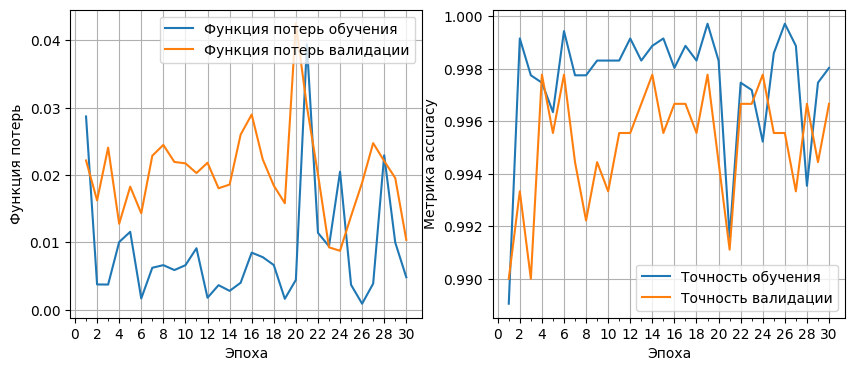

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(np.arange(1, EPOCHS_PT1 + EPOCHS_PT2 + 1), history['loss'], label='Функция потерь обучения')
axs[0].plot(np.arange(1, EPOCHS_PT1 + EPOCHS_PT2 + 1), history['val_loss'], label='Функция потерь валидации')
axs[0].grid()
axs[0].set_xticks(np.arange(0, EPOCHS_PT1 + EPOCHS_PT2 + 1, 2))
axs[0].set_xticks(np.arange(0, EPOCHS_PT1 + EPOCHS_PT2 + 1, 1), minor=True)
axs[0].legend(prop={'size': 10})
axs[0].set_xlabel('Эпоха')
axs[0].set_ylabel('Функция потерь')

axs[1].plot(np.arange(1, EPOCHS_PT1 + EPOCHS_PT2 + 1), history['accuracy'], label='Точность обучения')
axs[1].plot(np.arange(1, EPOCHS_PT1 + EPOCHS_PT2 + 1), history['val_accuracy'], label='Точность валидации')
axs[1].grid()
axs[1].set_xticks(np.arange(0, EPOCHS_PT1 + EPOCHS_PT2 + 1, 2))
axs[1].set_xticks(np.arange(0, EPOCHS_PT1 + EPOCHS_PT2 + 1, 1), minor=True)
axs[1].legend(prop={'size': 10})
axs[1].set_xlabel('Эпоха')
axs[1].set_ylabel('Метрика accuracy')
plt.show()

Работа модели:

In [ ]:
# Get one batch of test data
dataloader_test2 = DataLoader(dataset_test, batch_size=32, shuffle=True, num_workers=2)
dataiter = iter(dataloader_test2)
images, labels = next(dataiter)

# Move images to the same device
images = images.to(device)
model_pt.to(device)

# Make prediction
with torch.no_grad():
    outputs = model_pt(images)
    predicted = (torch.sigmoid(outputs) > 0.5).float()

# Print actual and predicted labels for the first few samples
print("Actual Labels:\t\t", labels[:20].cpu().numpy())
print("Predicted Labels:\t", predicted[:20].squeeze().cpu().numpy().astype(np.int64))

Actual Labels:		 [0 1 1 1 0 0 0 0 1 1 1 1 1 0 0 0 1 1 0 1]
Predicted Labels:	 [0 1 1 1 1 0 0 0 1 1 1 1 1 0 0 0 1 1 0 1]
